In [14]:
# ../data/train_congestion_data.csv 에서 dataframe 불러오기
import pandas as pd

df = pd.read_csv('../data/train_congestion_data.csv')
df.head()

,congestion_id,created_at,updated_at,congestion_cars,day_of_week,direction,measured_at,stat_end_date,stat_start_date,station_id,station_id.1,created_at.1,line_name,station_code,station_name,updated_at.1,latitude,longitude
0,135337,2026-01-25 13:07:46.493703,2026-01-25 13:07:46.493703,"[71, 70, 63, 83, 74, 65, 61, 67, 47, 40]",1,0,17:40:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
1,135338,2026-01-25 13:07:46.495483,2026-01-25 13:07:46.495483,"[63, 54, 65, 66, 55, 65, 75, 54, 52, 41]",1,1,17:30:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
2,135342,2026-01-25 13:07:46.505253,2026-01-25 13:07:46.505253,"[40, 47, 44, 48, 39, 55, 48, 39, 49, 30]",1,1,17:50:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
3,135345,2026-01-25 13:07:46.510723,2026-01-25 13:07:46.510723,"[50, 66, 60, 72, 63, 58, 64, 60, 48, 28]",1,0,17:30:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174
4,135346,2026-01-25 13:07:46.512792,2026-01-25 13:07:46.512792,"[53, 60, 64, 61, 62, 63, 67, 58, 56, 44]",1,1,17:40:00.000000,2026-01-22,2025-10-23,91,91,2026-01-25 09:36:55.194088,2호선,220,선릉역,2026-01-26 02:10:29.685580,37.504257,127.048174


In [15]:
# station_name 이 '역삼역'인 데이터만 필터링
df_yeoksam = df[(df['station_name'] == '역삼역')]

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import ast  # 문자열 형태의 리스트를 실제 리스트로 변환하기 위한 라이브러리

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')

# 마이너스 기호(-)가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

RAINBOW_COLORS = [
    "#FF0000", # 빨 (Mon)
    "#FF7F00", # 주 (Tue)
    "#FFD700", # 노 (Wed)
    "#1DC11D", # 초 (Thu)
    "#6969E4", # 파 (Fri)
    "#A049DF", # 남 (Sat)
    "#DB47A2"  # 보 (Sun)
]
DAY_MAP = {1: '월', 2: '화', 3: '수', 4: '목', 5: '금', 6: '토', 7: '일'}
DAY_ORDER = ['월', '화', '수', '목', '금', '토', '일']

In [17]:
# --- 2. 데이터 전처리 함수 ---
def preprocess_congestion_data(df, direction):
    """특정 방향 데이터를 필터링하고 분석 가능한 형태로 펼침"""
    # 기본 필터링 및 복사
    df_filtered = df[df['direction'] == direction].copy()
    
    # 리스트 파싱 (문자열인 경우만)
    df_filtered['congestion_cars'] = df_filtered['congestion_cars'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
    )
    
    # 펼치기 및 숫자 변환
    df_processed = df_filtered.explode('congestion_cars')
    df_processed['congestion_cars'] = pd.to_numeric(df_processed['congestion_cars'], errors='coerce')
    
    # 정렬 및 요일 이름 매핑
    df_processed = df_processed.sort_values(by=['day_of_week', 'measured_at'])
    df_processed['day_name'] = df_processed['day_of_week'].map(DAY_MAP)
    
    return df_processed

# --- 3. 시각화 함수 ---
def plot_congestion_line(df, title):
    """시간 흐름에 따른 라인 플롯 생성"""
    plt.figure(figsize=(16, 8))
    sns.lineplot(
        data=df, x='measured_at', y='congestion_cars', hue='day_name',
        errorbar=None, palette=RAINBOW_COLORS, marker='o', hue_order=DAY_ORDER
    )
    plt.title(f'혼잡도 추이: {title}', fontsize=15)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_congestion_box(df, title):
    """시간/요일별 분포를 보여주는 박스 플롯 생성"""
    plt.figure(figsize=(20, 10))
    sns.boxplot(
        data=df, x='measured_at', y='congestion_cars', hue='day_name',
        palette=RAINBOW_COLORS, hue_order=DAY_ORDER, showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "6"},
        fliersize=3
    )
    plt.title(f'혼잡도 분포: {title}', fontsize=15)
    plt.xlabel('측정 시간')
    plt.ylabel('혼잡도 (%)')
    plt.legend(title='요일', loc='best')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [18]:
def draw_car_boxplot_by_day(df_input, direction_val, title_suffix):
    # 1. 전처리: 역삼역, 평일(0~4), 특정 방향, 특정 시간대
    # day_of_week: 0(월) ~ 4(금)
    df_filtered = df_input[
        (df_input['station_name'] == '역삼역') & 
        (df_input['day_of_week'].isin([1, 2, 3, 4, 5])) & 
        (df_input['direction'] == direction_val)
    ].copy()

    # 2. 요일 숫자(0~4)를 한글('월'~'금')로 매핑
    df_filtered['day_name'] = df_filtered['day_of_week'].map(DAY_MAP)

    # 3. 데이터 변환 (문자열 리스트 -> 실제 리스트)
    df_filtered['congestion_cars'] = df_filtered['congestion_cars'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # 4. 데이터 구조 재구성
    plot_data = []
    for _, row in df_filtered.iterrows():
        for car_idx, val in enumerate(row['congestion_cars'], start=1):
            plot_data.append({
                '요일': row['day_name'],
                '칸': car_idx,
                '혼잡도': val
            })
    df_plot = pd.DataFrame(plot_data)

    # 5. 그래프 그리기 (2행 1열)
    fig, axes = plt.subplots(2, 1, figsize=(20, 16))
    
    # -------------------------------------------------------
    # [상단] 박스플롯: 요일별 분포
    # -------------------------------------------------------
    sns.boxplot(
        data=df_plot, 
        x='칸', 
        y='혼잡도', 
        hue='요일',           # 색상 기준을 요일로 변경
        hue_order=DAY_ORDER,  # 월->금 순서 고정
        palette=RAINBOW_COLORS,    # 요일별 구분 잘 되는 색상 테마
        width=0.7,
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "5"},
        flierprops={"markersize": 3},
        ax=axes[0]
    )
    axes[0].set_title(f'역삼역 요일별 칸별 혼잡도 분포 (Boxplot) - {title_suffix}', fontsize=16)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('혼잡도 (%)', fontsize=12)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    axes[0].legend(title='요일', loc='best')

    # -------------------------------------------------------
    # [하단] 라인플롯: 요일별 평균 추세
    # -------------------------------------------------------
    sns.lineplot(
        data=df_plot,
        x='칸',
        y='혼잡도',
        hue='요일',           # 색상 기준을 요일로 변경
        hue_order=DAY_ORDER,  # 월->금 순서 고정
        palette=RAINBOW_COLORS,
        estimator='mean',
        errorbar=None,
        marker='o',
        markersize=8,
        linewidth=2.5,
        ax=axes[1]
    )
    axes[1].set_title(f'역삼역 요일별 칸별 혼잡도 평균 추세 (Lineplot) - {title_suffix}', fontsize=16)
    axes[1].set_xlabel('열차 칸 번호 (1-10)', fontsize=12)
    axes[1].set_ylabel('평균 혼잡도 (%)', fontsize=12)
    axes[1].grid(True, axis='both', linestyle='--', alpha=0.5)
    axes[1].legend(title='요일', loc='best')

    # x축 눈금 보정 (데이터와 일치화)
    axes[1].set_xticks(range(1, 11))
    axes[1].set_xticklabels(range(1, 11))
    axes[1].set_xlim(0.5, 10.5) # 박스플롯과 좌우 여백 맞춤

    plt.tight_layout()
    plt.show()


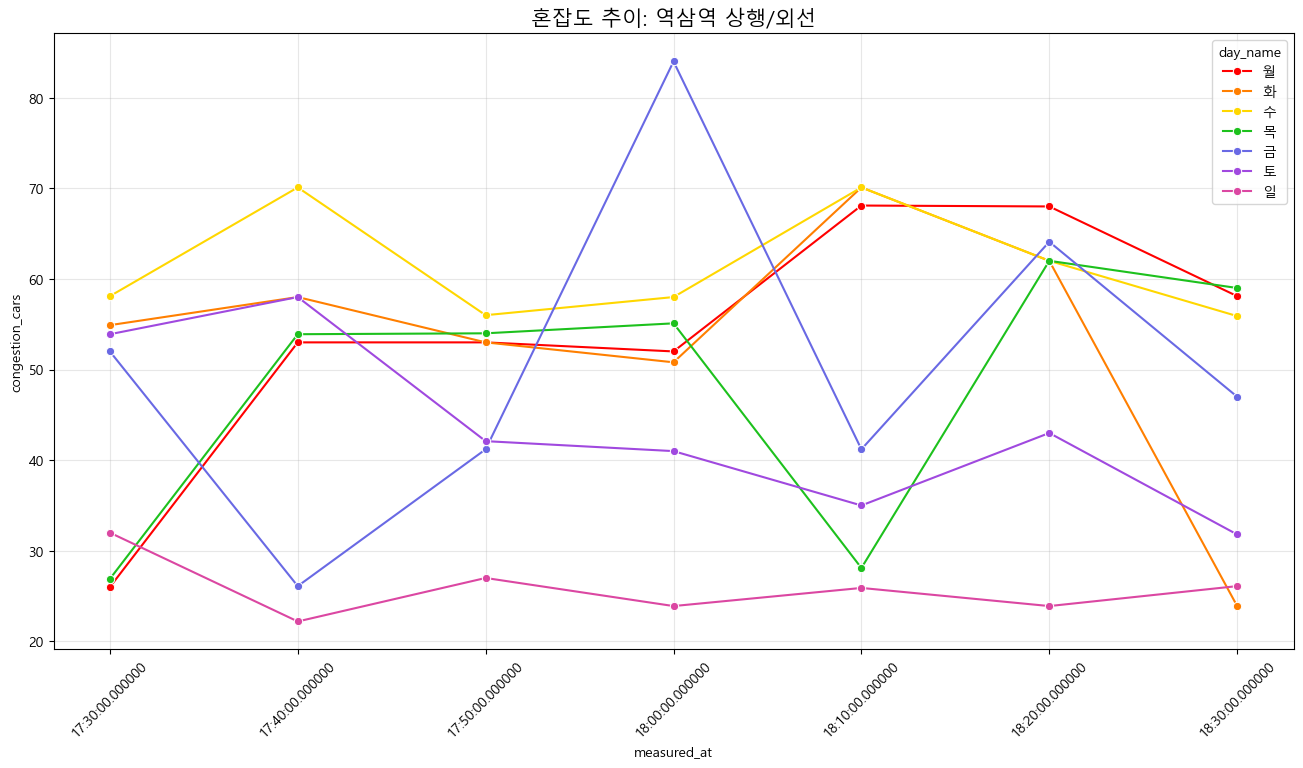

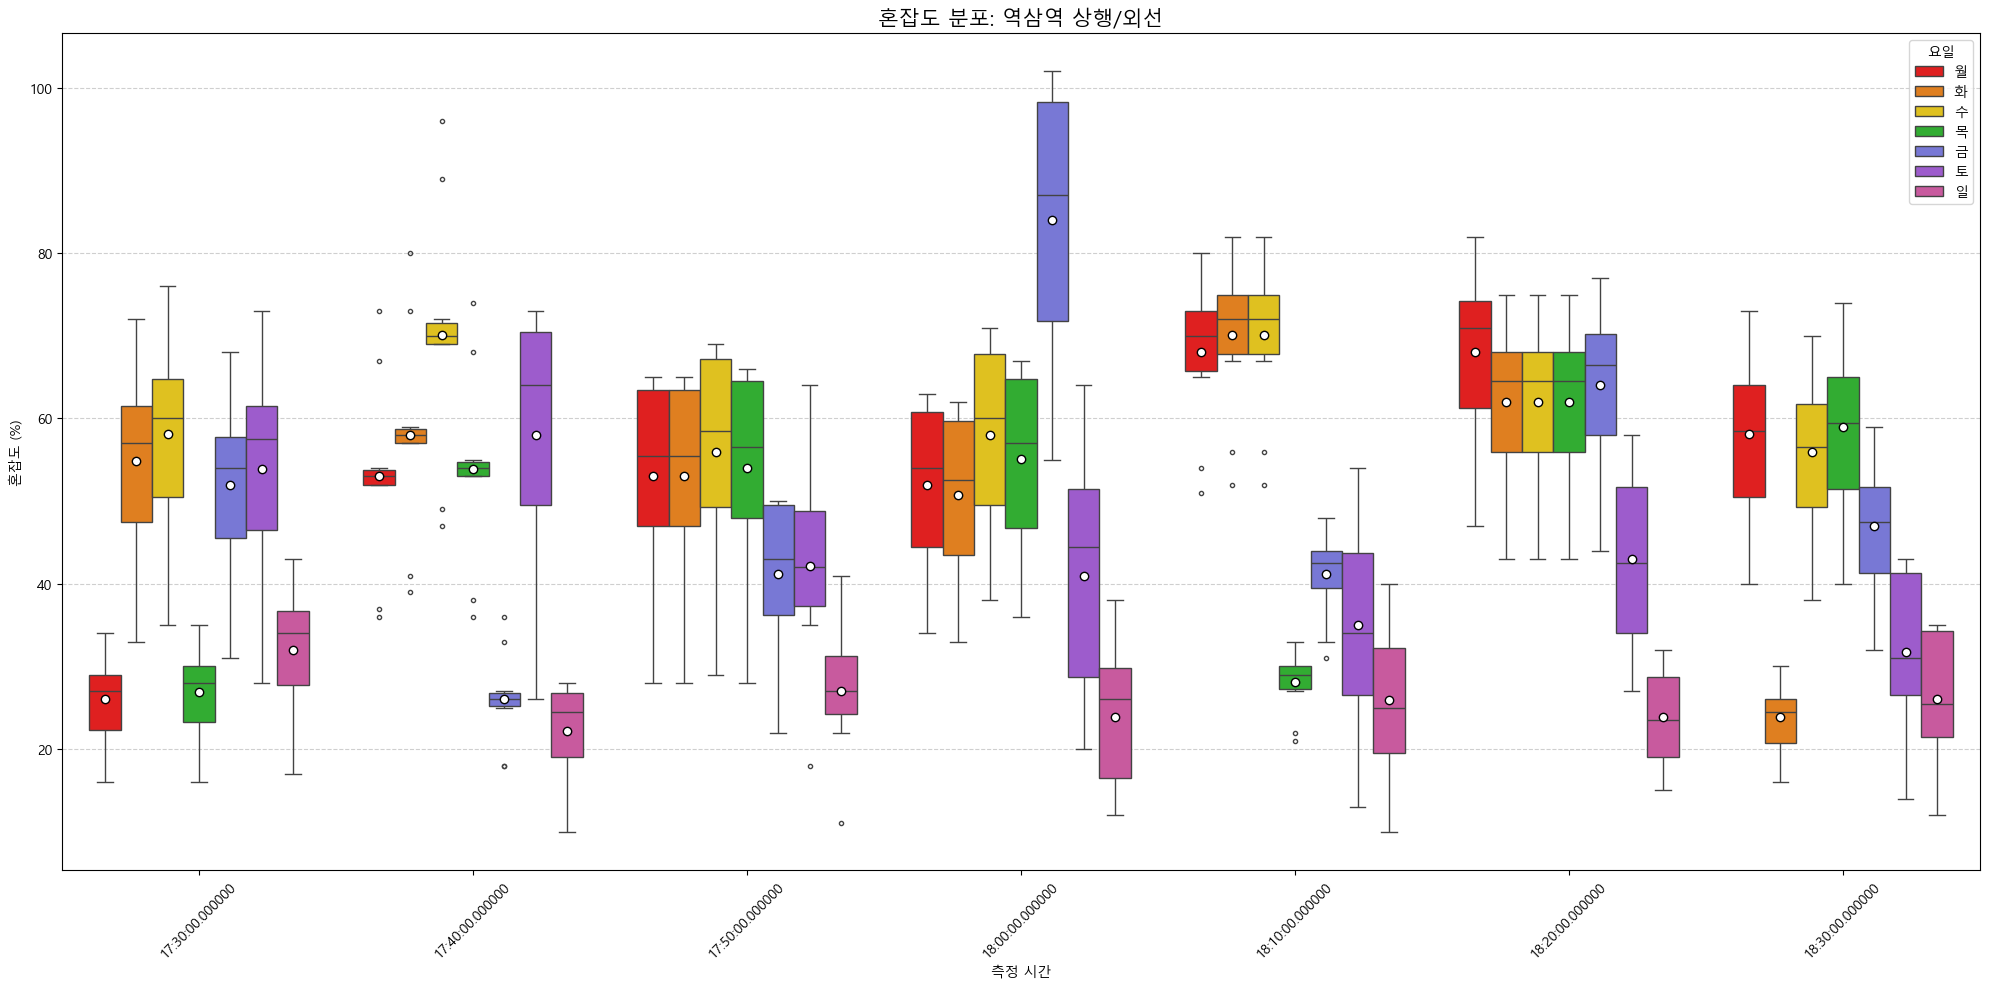

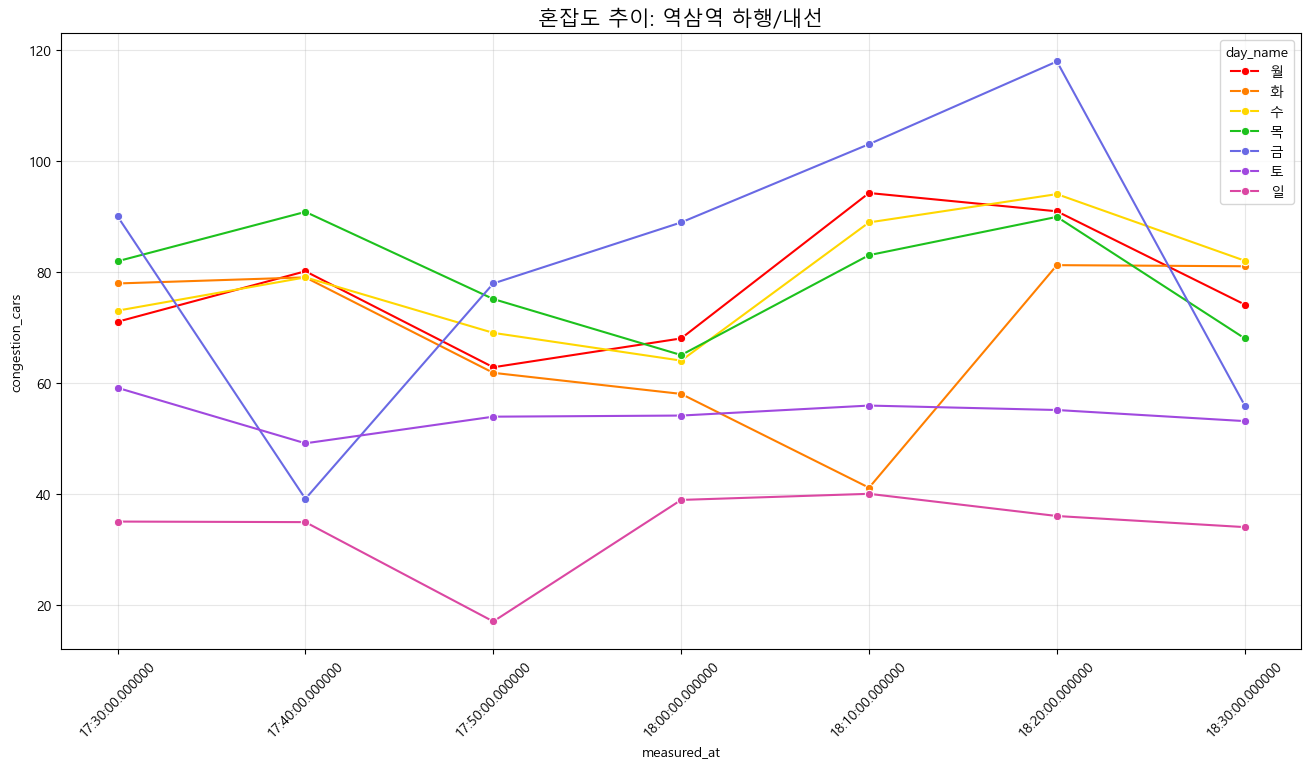

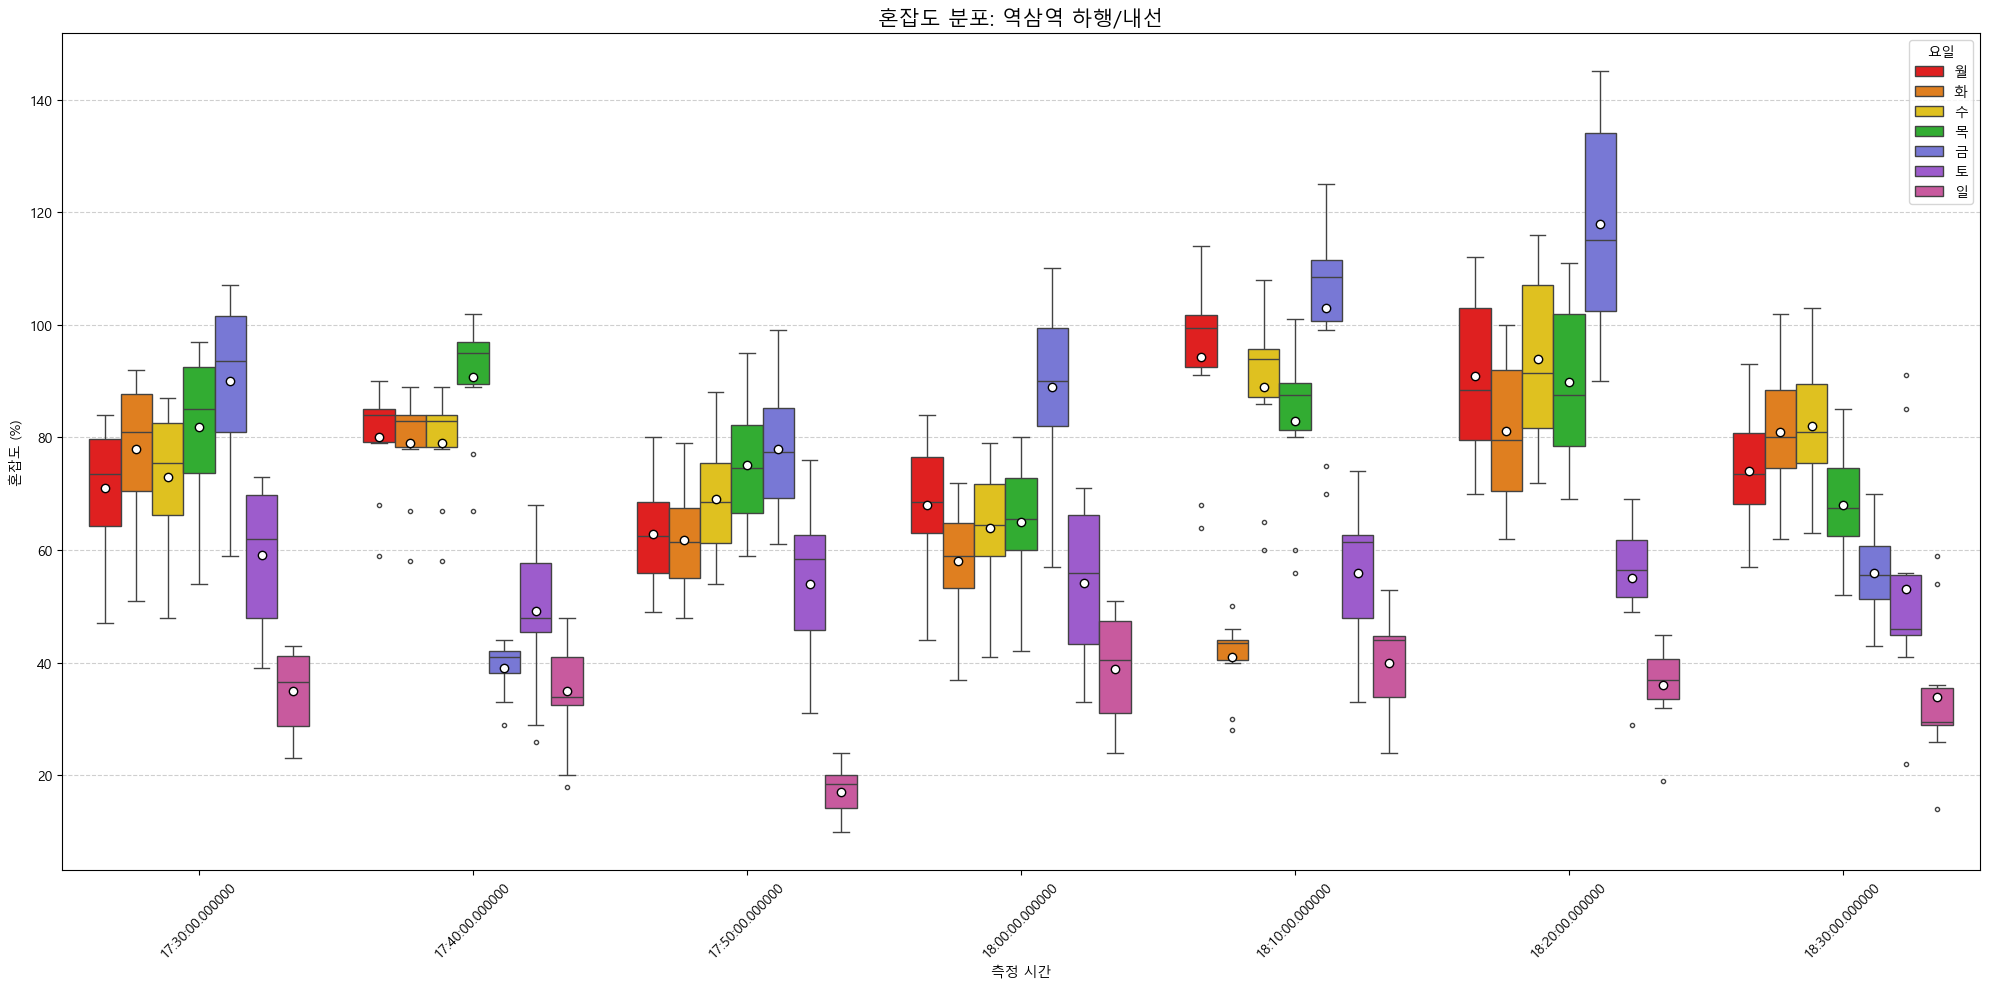

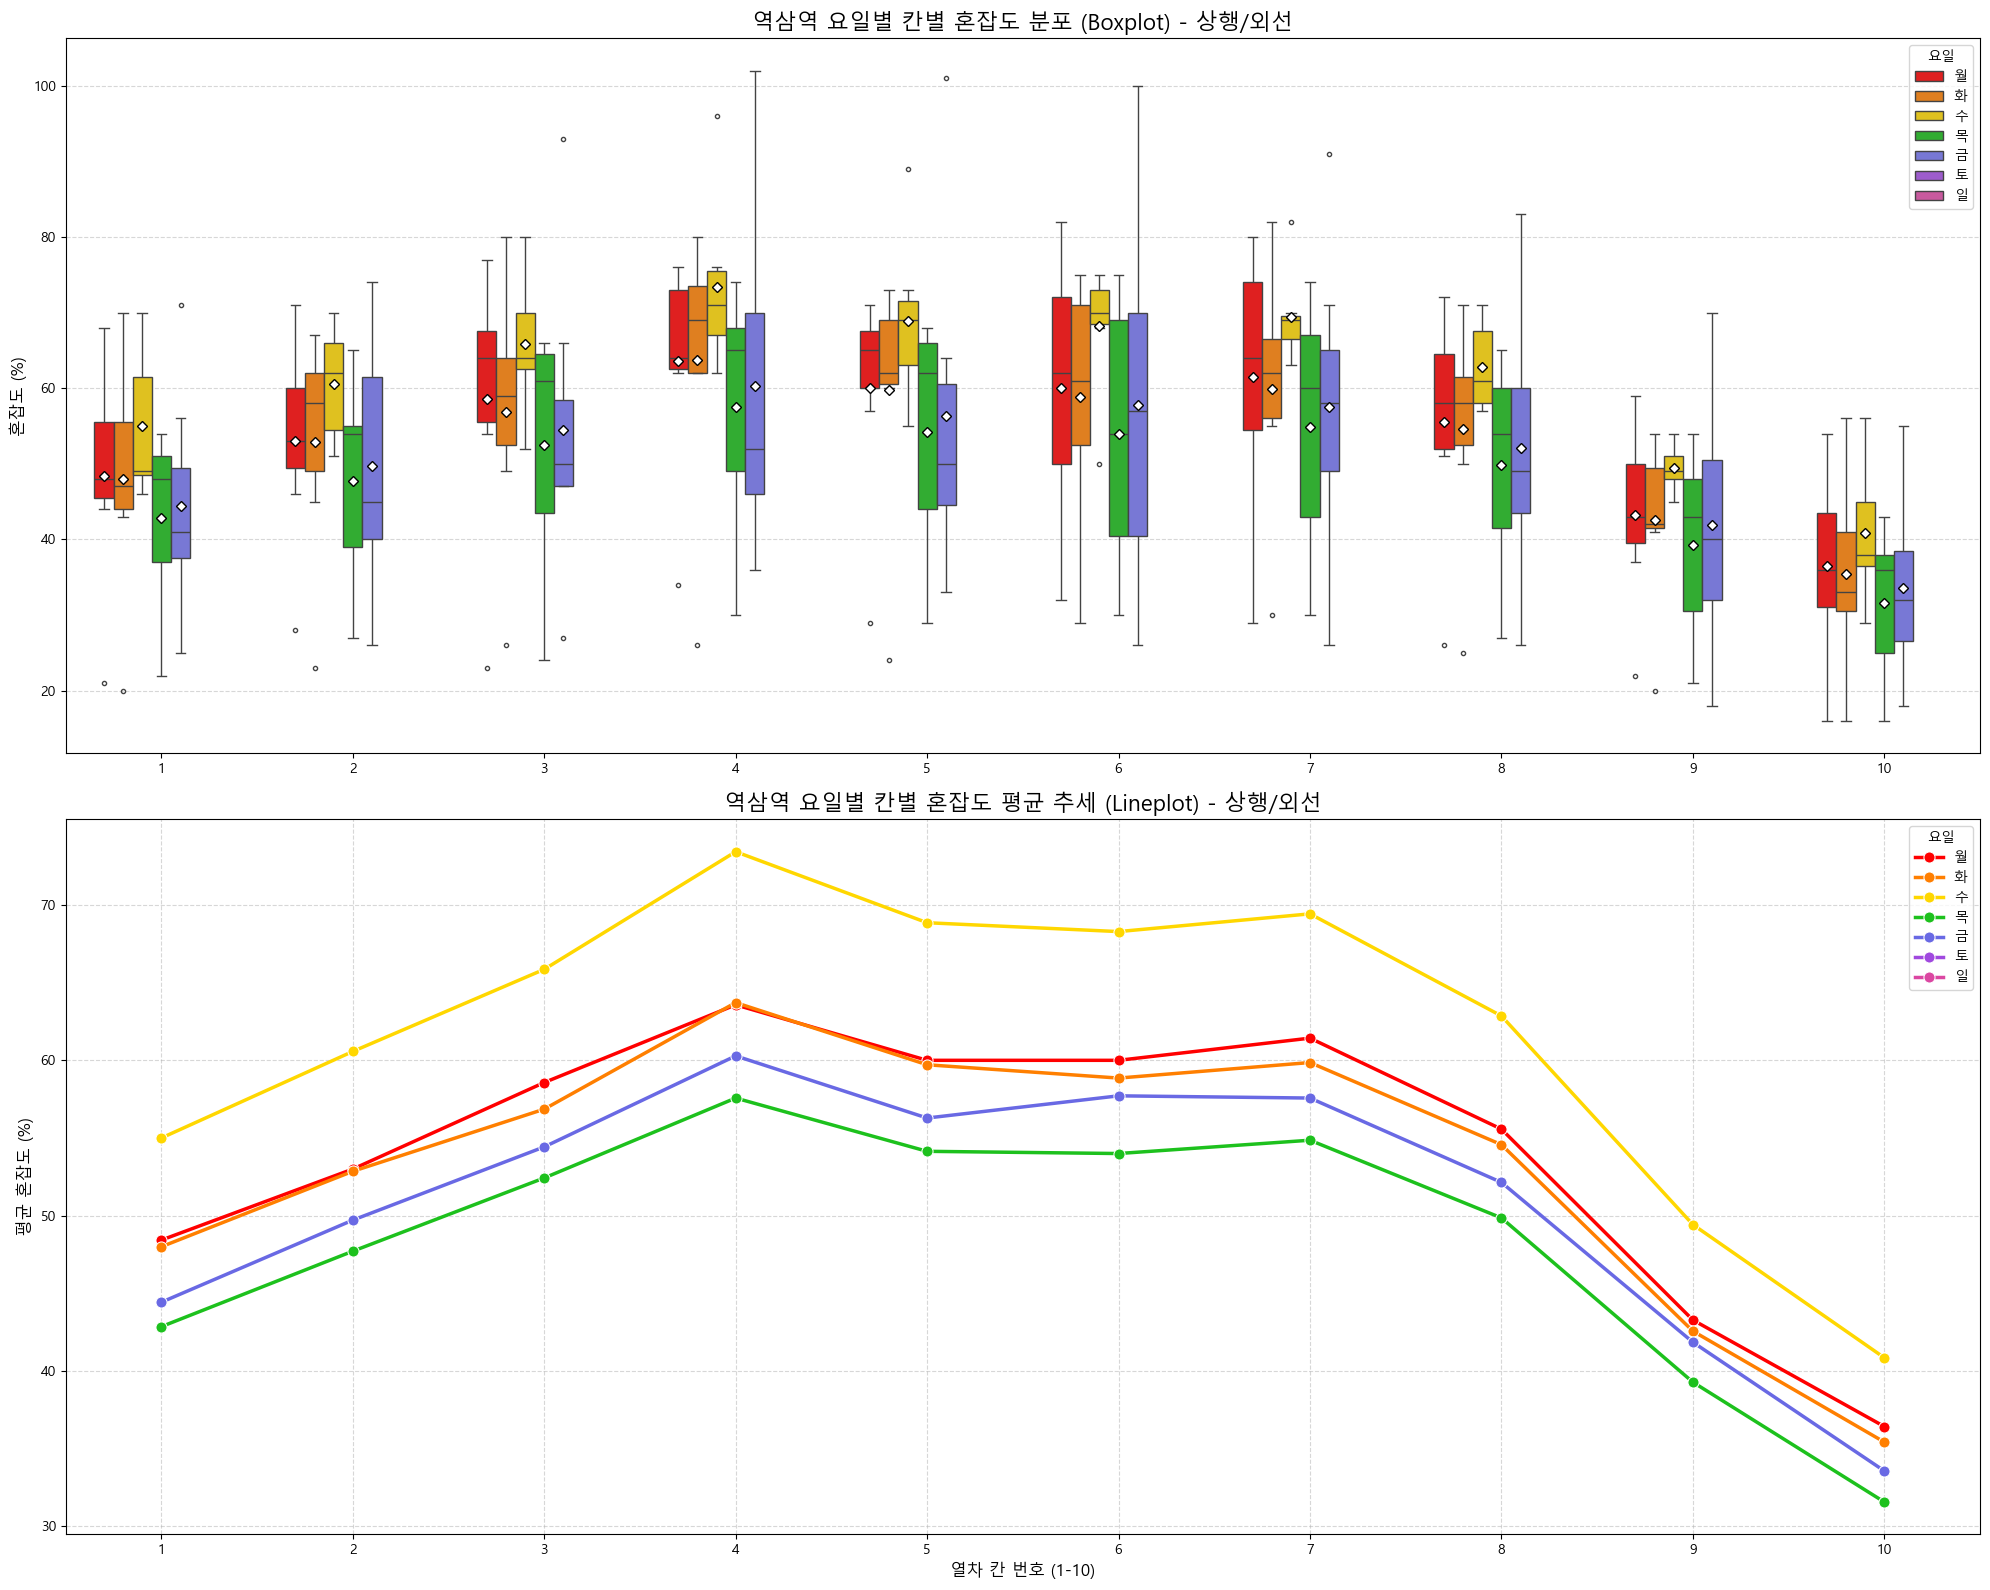

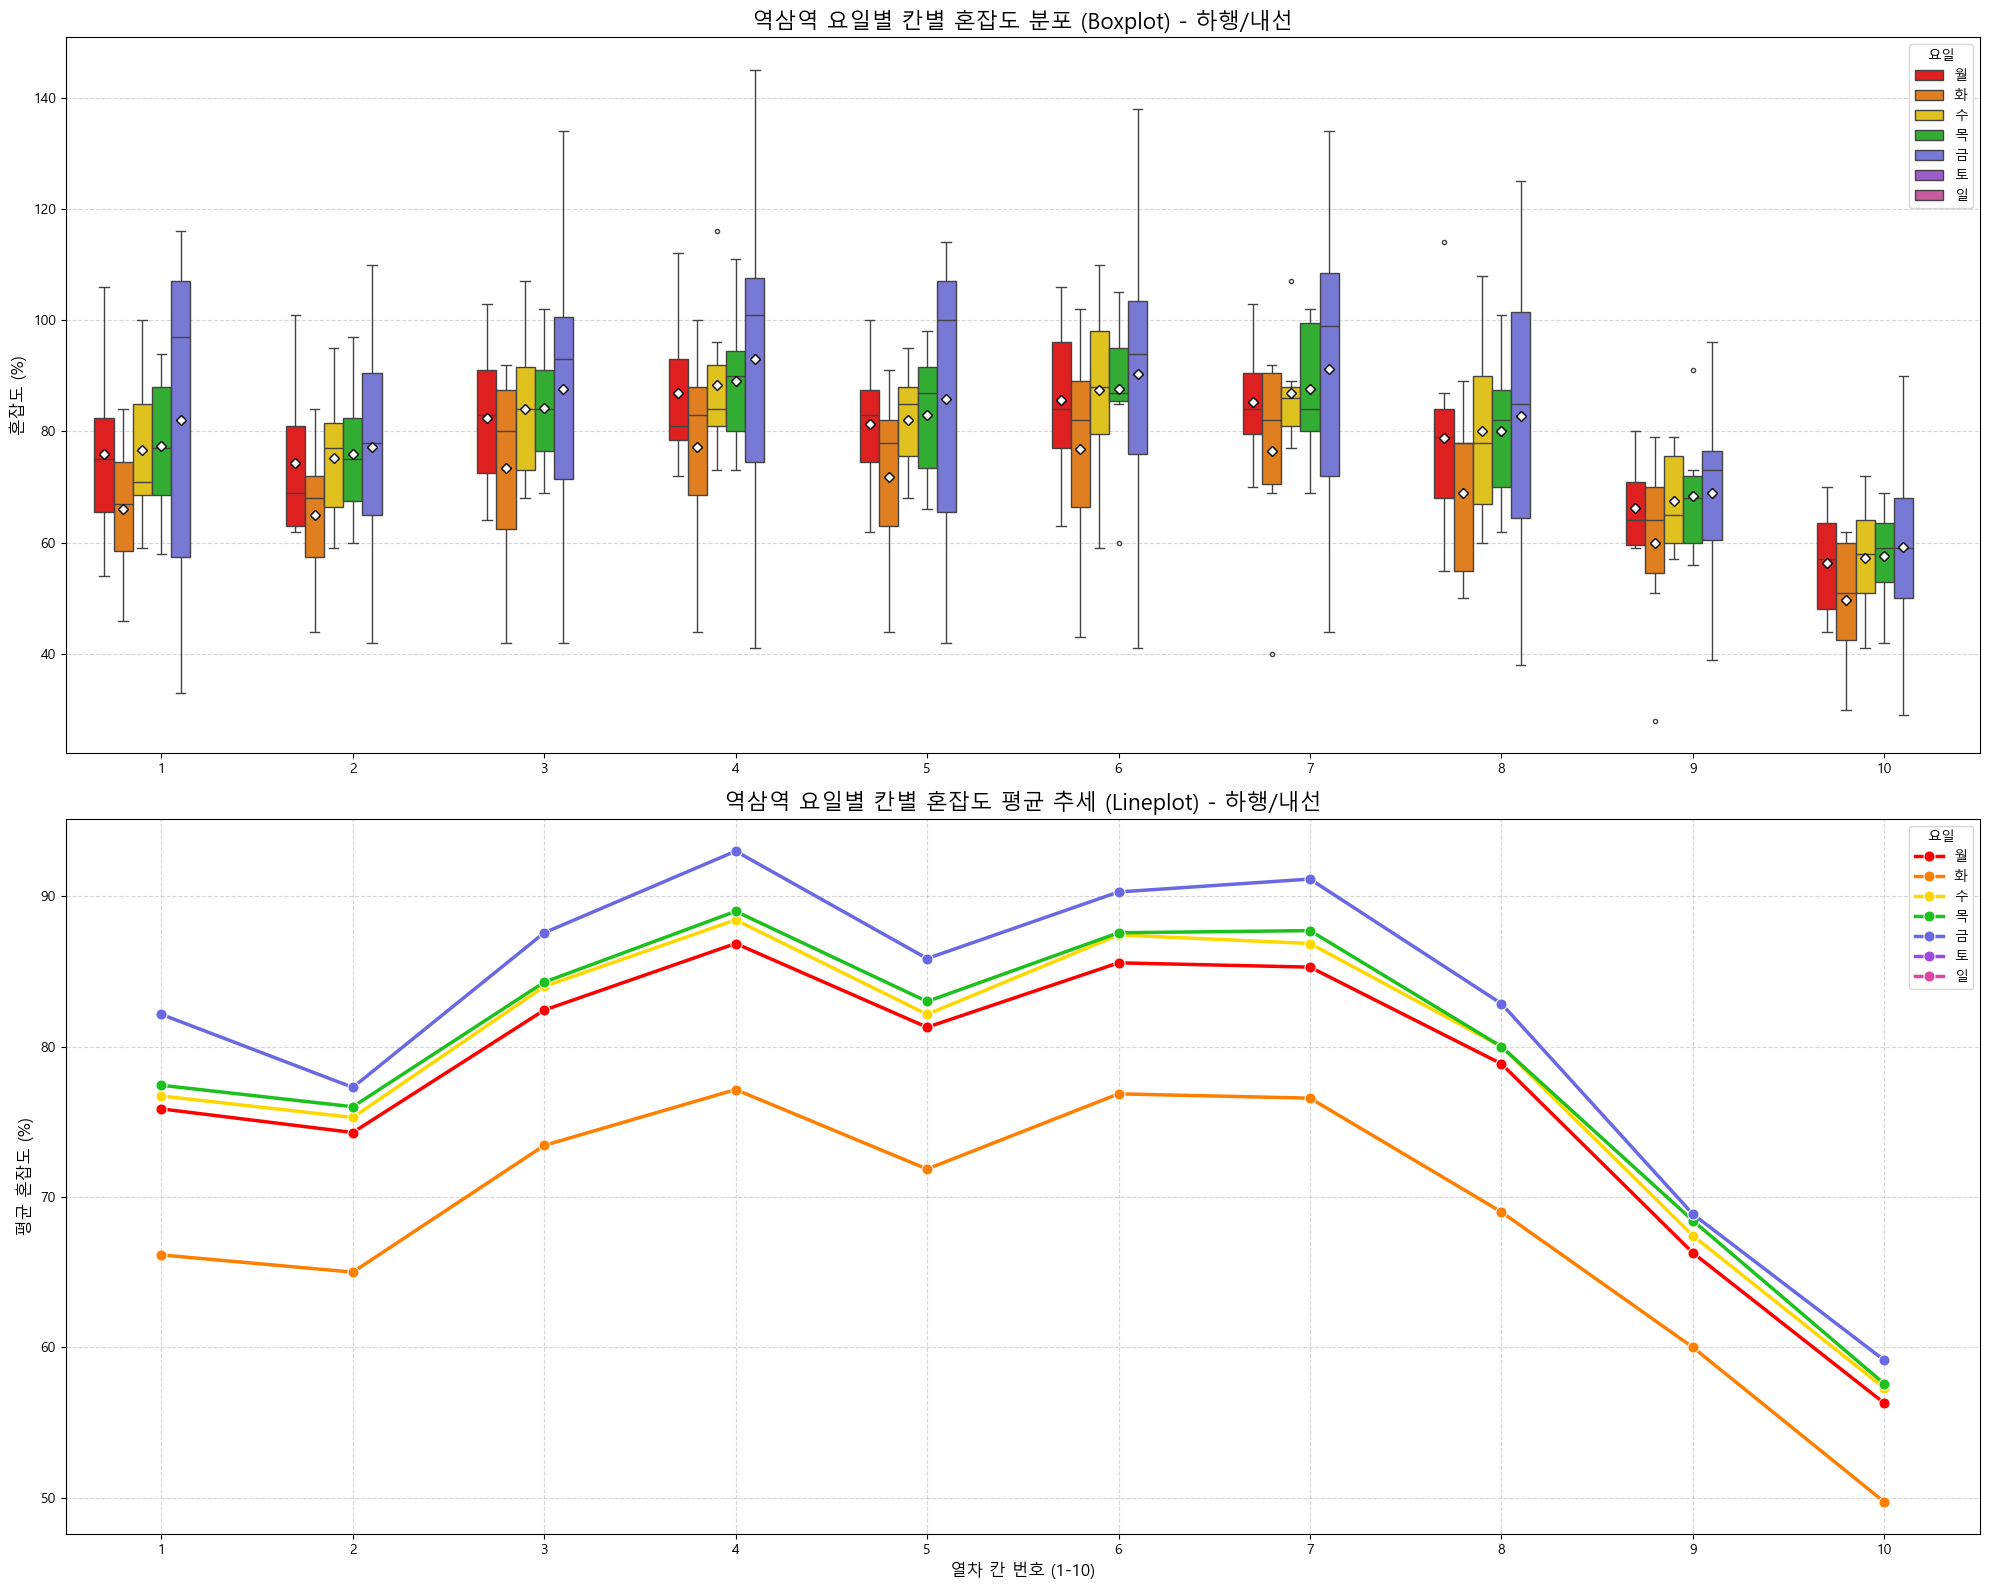

In [19]:
# 실행
directions = {
    0: "역삼역 상행/외선",
    1: "역삼역 하행/내선"
}

for d_val, d_name in directions.items():
    # 데이터 가공
    df_final = preprocess_congestion_data(df_yeoksam, d_val)
    
    # 그래프 출력
    plot_congestion_line(df_final, d_name)
    plot_congestion_box(df_final, d_name)


draw_car_boxplot_by_day(df, 0, "상행/외선")
draw_car_boxplot_by_day(df, 1, "하행/내선")